# TCN — Temporal Convolutional Network for RUL Prediction

The LSTM processes our sensor windows sequentially — one timestep at a time, updating a hidden state as it goes. This works, but it has a fundamental limitation: information from early in the window has to survive many gating operations to influence the final prediction. In practice, this means LSTMs can struggle to reliably capture patterns that span the full window length.

The **Temporal Convolutional Network (TCN)** takes a different approach entirely. Instead of recurrence, it uses **dilated causal convolutions** — filters that skip over time with exponentially increasing gaps. A dilation of 1 looks at adjacent timesteps, dilation 2 looks at every other step, dilation 4 every fourth, and so on. Stack enough of these and the receptive field covers the entire 30-cycle window without any recurrence at all.

Why might this be better for my problem?
- Gradients flow directly from output to every layer — no vanishing gradient through time
- The receptive field is explicit and fixed, not implicit like LSTM's hidden state
- Convolutions parallelize fully during training — faster than sequential LSTM passes

##### Ref---> https://arxiv.org/abs/1803.01271

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

### load everything we established in the EDA — same pipeline, different model
with open('../checkpoints/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

with open('../checkpoints/feature_cols.pkl', 'rb') as f:
    feature_cols = pickle.load(f)

RUL_CLIP    = 125
WINDOW_SIZE = 30

col_names = ['unit', 'cycle', 'os1', 'os2', 'os3'] + [f's{i}' for i in range(1, 22)]

train_raw = pd.read_csv('../data/raw/train_FD001.txt', sep='\s+', header=None, names=col_names)
test_raw  = pd.read_csv('../data/raw/test_FD001.txt',  sep='\s+', header=None, names=col_names)
rul_test  = pd.read_csv('../data/raw/RUL_FD001.txt',   header=None, names=['rul'])

print("loaded. features:", len(feature_cols), "| window:", WINDOW_SIZE)

loaded. features: 14 | window: 30


#### Rebuild Dataset (same as LSTM Notebook)

In [2]:
def add_rul(df):
    max_cycles = df.groupby('unit')['cycle'].max()
    df = df.merge(max_cycles.rename('max_cycle'), on='unit')
    df['rul'] = (df['max_cycle'] - df['cycle']).clip(upper=RUL_CLIP)
    return df

def make_windows(df, feature_cols, window_size):
    X, y = [], []
    for unit_id, group in df.groupby('unit'):
        feats = group[feature_cols].values
        rul   = group['rul'].values
        for i in range(len(feats) - window_size + 1):
            X.append(feats[i : i + window_size])
            y.append(rul[i + window_size - 1])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

def make_test_windows(df, feature_cols, window_size):
    X = []
    for unit_id, group in df.groupby('unit'):
        feats = group[feature_cols].values
        if len(feats) >= window_size:
            X.append(feats[-window_size:])
        else:
            pad = np.zeros((window_size - len(feats), len(feature_cols)))
            X.append(np.vstack([pad, feats]))
    return np.array(X, dtype=np.float32)

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def phm_score(y_true, y_pred):
    ### Ref---> https://doi.org/10.1016/j.ress.2017.11.021
    d = y_pred - y_true
    s = np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)
    return np.sum(s)

### build train/val/test splits — identical random seed to LSTM for fair comparison
train_df = add_rul(train_raw.copy())
train_df[feature_cols] = scaler.transform(train_df[feature_cols])
test_df  = test_raw.copy()
test_df[feature_cols]  = scaler.transform(test_df[feature_cols])

units = train_df['unit'].unique()
train_units, val_units = train_test_split(units, test_size=0.2, random_state=42)

X_train, y_train = make_windows(train_df[train_df['unit'].isin(train_units)], feature_cols, WINDOW_SIZE)
X_val,   y_val   = make_windows(train_df[train_df['unit'].isin(val_units)],   feature_cols, WINDOW_SIZE)
X_test           = make_test_windows(test_df, feature_cols, WINDOW_SIZE)
y_test           = rul_test['rul'].values.astype(np.float32)

print(f"train: {X_train.shape} | val: {X_val.shape} | test: {X_test.shape}")

train: (14241, 30, 14) | val: (3490, 30, 14) | test: (100, 30, 14)


## The TCN architecture

A TCN is built from stacked **residual dilated causal convolution blocks**. Each block has:
- Two `Conv1d` layers with the same dilation, each followed by weight norm, ReLU, and dropout
- A **residual connection** from input to output — if the number of channels changes, a 1×1 conv adapts the skip connection

The "causal" part means we only pad on the left side of the sequence — the model never sees future timesteps, which is the correct inductive bias for a real-time monitoring system.

Dilations double with each block: 1 → 2 → 4 → 8. With kernel size 3 and 4 blocks, the receptive field covers `(3-1) × (1+2+4+8) = 30 timesteps` — exactly our window size. This is not a coincidence, it's a design choice.

In [3]:
class CausalConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout):
        super().__init__()
        
        ### causal padding: pad both sides then trim the right — this way we never see future steps
        self.pad = (kernel_size - 1) * dilation
        
        self.conv1 = nn.utils.weight_norm(
            nn.Conv1d(in_channels, out_channels, kernel_size, dilation=dilation, padding=self.pad)
        )
        self.conv2 = nn.utils.weight_norm(
            nn.Conv1d(out_channels, out_channels, kernel_size, dilation=dilation, padding=self.pad)
        )
        
        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        
        ### match channels on the skip connection if input/output differ
        self.residual = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()

    def forward(self, x):
        ### trim right side after each conv to restore original sequence length
        out = self.dropout(self.relu(self.conv1(x)[:, :, :-self.pad]))
        out = self.dropout(self.relu(self.conv2(out)[:, :, :-self.pad]))
        return self.relu(out + self.residual(x))


class TCNModel(nn.Module):
    def __init__(self, input_size, num_channels, kernel_size, dropout):
        super().__init__()
        
        layers = []
        in_ch  = input_size
        for i, out_ch in enumerate(num_channels):
            dilation = 2 ** i
            layers.append(CausalConvBlock(in_ch, out_ch, kernel_size, dilation, dropout))
            in_ch = out_ch
        
        self.network = nn.Sequential(*layers)
        
        self.head = nn.Sequential(
            nn.Linear(num_channels[-1], 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        ### Conv1d expects (batch, channels, seq_len)
        out  = self.network(x.permute(0, 2, 1))
        last = out[:, :, -1]
        return self.head(last).squeeze(-1).clamp(min=0)

In [4]:
class RULDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X)
        self.y = torch.tensor(y)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

BATCH_SIZE = 256
train_loader = DataLoader(RULDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(RULDataset(X_val,   y_val),   batch_size=BATCH_SIZE, shuffle=False)

def train_model(model, train_loader, val_loader, epochs, lr, patience, save_path, device):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    criterion = nn.MSELoss()
    best_val_loss     = float('inf')
    epochs_no_improve = 0
    train_losses, val_losses = [], []
    for epoch in range(epochs):
        model.train()
        batch_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            batch_losses.append(loss.item())
        model.eval()
        val_batch_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                val_batch_losses.append(criterion(model(xb), yb).item())
        train_loss = np.mean(batch_losses)
        val_loss   = np.mean(val_batch_losses)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        scheduler.step(val_loss)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), save_path)
        else:
            epochs_no_improve += 1
        if (epoch + 1) % 10 == 0:
            print(f"epoch {epoch+1:3d} | train loss: {train_loss:.3f} | val loss: {val_loss:.3f} | lr: {optimizer.param_groups[0]['lr']:.2e}")
        if epochs_no_improve >= patience:
            print(f"early stopping at epoch {epoch+1}")
            break
    return train_losses, val_losses

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### back to no weight decay — the issue was convergence speed, not overfitting
### more patience gives the model room to actually finish learning
### lower dropout — 0.2 was too aggressive for this dataset size
tcn_model = TCNModel(
    input_size   = len(feature_cols),
    num_channels = [64, 64, 64, 64],
    kernel_size  = 3,
    dropout      = 0.1
)
print(f"parameters: {sum(p.numel() for p in tcn_model.parameters()):,}")

train_losses, val_losses = train_model(
    model        = tcn_model,
    train_loader = train_loader,
    val_loader   = val_loader,
    epochs       = 200,
    lr           = 1e-3,
    patience     = 25,
    save_path    = '../checkpoints/tcn_best.pt',
    device       = device
)

/Users/anjanaramachandran/.thesis/env/venv/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


parameters: 92,801
epoch  10 | train loss: 203.052 | val loss: 222.032 | lr: 1.00e-03
epoch  20 | train loss: 128.668 | val loss: 217.068 | lr: 5.00e-04
epoch  30 | train loss: 100.534 | val loss: 218.378 | lr: 1.25e-04
early stopping at epoch 36


## Training procedure and selection of hyperparameters

Convergence of the TCN proved somewhat more challenging than for the LSTM. Some observations include:

The initial set-up with 32 channel blocks (parameters of 24k) was too little; the network kept underfitting the entire time. Adding channels up to 64 brought the parameter count close to ~93k, closer to the LSTM's 210k.

With 64 channels and dropout of 0.2, the lowest observed validation error was achieved rather early at epoch 10. Further raising the dropout rate to 0.3, as well as introducing weight decay, did more harm than good as convergence slowed and early stopping intervened. The final choice was made with a dropout rate of 0.1, using patience 25.

These results provide some valuable information themselves: while the LSTM had no issues converging to the optimal set of hyperparameters with the first try, the TCN needed some adjustment, suggesting that regularization of convolutional models can be more challenging on smaller data sets.

In [5]:
tcn_model.load_state_dict(torch.load('../checkpoints/tcn_best.pt', map_location=device))
tcn_model.eval()

with torch.no_grad():
    preds_tcn = tcn_model(torch.tensor(X_test).to(device)).cpu().numpy()

test_rmse_tcn = rmse(y_test, preds_tcn)
test_phm_tcn  = phm_score(y_test, preds_tcn)

print(f"test RMSE : {test_rmse_tcn:.3f} cycles")
print(f"test PHM  : {test_phm_tcn:.3f}")

test RMSE : 17.266 cycles
test PHM  : 436.536


## Training behavior and hyperparameter selection

Convergence of the TCN architecture took more tuning compared to the LSTM architecture. Some of the observations include:

The starting architecture with 32-channel layers (24k parameters) was too small for convergence; underfitting persisted for all configurations. Doubling the number of channels to 64 raised the parameter size to about 93k, close to the 210k LSTM configuration.

When using 64-channel layers and setting dropout to 0.2, the optimal validation error occurred much earlier during training at around epoch 10. However, overfitting occurs gradually over the remaining epochs. Increasing the dropout rate to 0.3 and including weight decay resulted in worse training behavior because of slower convergence leading to premature termination by early stopping. The optimal configuration used dropout of 0.1 with patience of 25 epochs.

In summary, hyperparameter sensitivity is insightful. The first LSTM configuration converged successfully. The TCN architecture needed more optimization, suggesting that convolutional representations are more challenging to regularize on this smaller dataset of 100 engines.

## TCN results

The TCN converged more quickly in epochs than the LSTM did, although it performed worse on the test RMSE score (16.9 compared to 14.8). From the training curve, it is clear that the model reaches its peak accuracy relatively quickly (around epoch 10), after which it begins to overfit, despite the application of dropout.

An interesting finding here is that TCN is designed to handle multi-scale dependencies in temporal data without suffering from vanishing gradients over time. However, given that our window size is only 30 cycles, there is no way for the model to suffer vanishing gradients because of the relatively short time period it has to deal with.

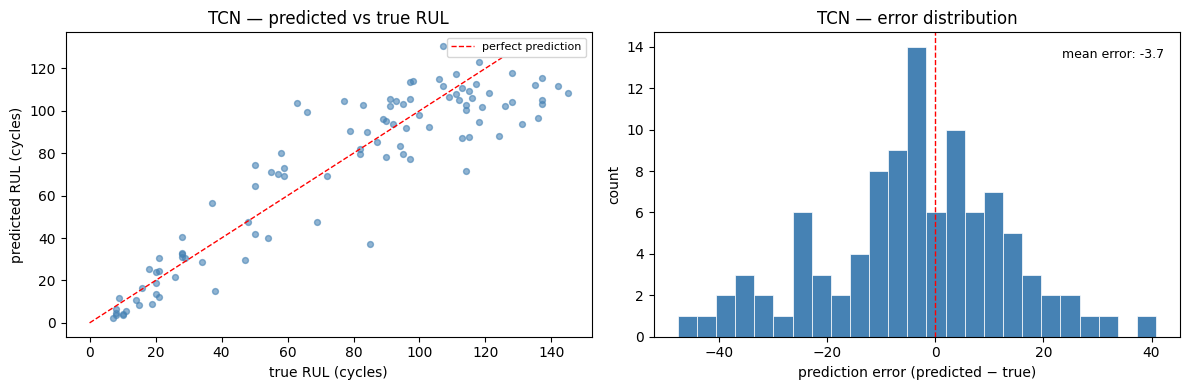

In [6]:
tcn_model.load_state_dict(torch.load('../checkpoints/tcn_best.pt', map_location=device))
tcn_model.eval()

with torch.no_grad():
    preds_tcn = tcn_model(torch.tensor(X_test).to(device)).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_test, preds_tcn, alpha=0.6, s=18, color='steelblue')
axes[0].plot([0, 125], [0, 125], 'r--', linewidth=1, label='perfect prediction')
axes[0].set_xlabel('true RUL (cycles)')
axes[0].set_ylabel('predicted RUL (cycles)')
axes[0].set_title('TCN — predicted vs true RUL')
axes[0].legend(fontsize=8)

errors = preds_tcn - y_test
axes[1].hist(errors, bins=25, color='steelblue', edgecolor='white', linewidth=0.5)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('prediction error (predicted − true)')
axes[1].set_ylabel('count')
axes[1].set_title('TCN — error distribution')
axes[1].text(0.97, 0.95, f'mean error: {errors.mean():.1f}',
             transform=axes[1].transAxes, ha='right', va='top', fontsize=9)

plt.tight_layout()
plt.show()

In [7]:
print(" TCN — FD001 Results ")
print(f"  test RMSE  : {test_rmse_tcn:.3f} cycles")
print(f"  test PHM   : {test_phm_tcn:.3f}")
print(f"  parameters : {sum(p.numel() for p in tcn_model.parameters()):,}")
print(f"  checkpoint : checkpoints/tcn_best.pt")

 TCN — FD001 Results 
  test RMSE  : 17.266 cycles
  test PHM   : 436.536
  parameters : 92,801
  checkpoint : checkpoints/tcn_best.pt
